In [1]:
%reload_ext autoreload
%autoreload 2
import sys, os
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import optax
from tqdm.notebook import tqdm

# Add project root to path
project_root = '/sdf/group/neutrino/pgranger/larnd-sim-jax/src'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%cd /sdf/group/neutrino/pgranger/larnd-sim-jax

from larndsim.consts_jax import build_params_class, load_detector_properties, load_lut
from larndsim.losses_jax import adc2charge
from optimize.strategies import LUTSimulation, LUTMarkovSimulation, MarkovLossStrategy
from optimize.dataio import TracksDataset, DataLoader
from optimize.ranges import ranges

def map_norm_to_phys(val, key, scheme="sigmoid", scale=1.0):
    if scheme == "sigmoid":
        low, high = ranges[key]['min'], ranges[key]['max']
        return low + (high - low) * jax.nn.sigmoid(scale * val)
    return val

def map_phys_to_norm(val, key, scheme="sigmoid", scale=1.0):
    if scheme == "sigmoid":
        low, high = ranges[key]['min'], ranges[key]['max']
        eps = jnp.finfo(jnp.float32).eps
        frac = jnp.clip((val - low) / (high - low), eps, 1.0 - eps)
        return jnp.log(frac / (1.0 - frac)) / scale
    return val

print("Setup complete.")

/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/sdf/group/neutrino/pgranger/larnd-sim-jax
Setup complete.


In [2]:
# --- Configuration ---
INPUT_FILE = '/sdf/data/neutrino/cyifan/diffsim_input/true_through_muon_edep_10cm_vol1cm.h5'
LUT_FILE = 'src/larndsim/detector_properties/response_44_v2a_full_tick.npz'
DET_PROPS = 'src/larndsim/detector_properties/module0.yaml'
PIXEL_LAYOUTS = 'src/larndsim/pixel_layouts/multi_tile_layout-2.4.16_v4.yaml'

RELEVANT_PARAMS = ['Ab', 'kb', 'lifetime', 'tran_diff', 'long_diff', 'eField', 'shift_x', 'shift_y', 'shift_z']

ELECTRON_SAMPLING_RESOLUTION = 0.1
NUMBER_PIX_NEIGHBORS = 4
SIGNAL_LENGTH = 150

# --- Setup Simulation Objects ---
ParamsClass = build_params_class(RELEVANT_PARAMS)
ref_params = load_detector_properties(ParamsClass, DET_PROPS, PIXEL_LAYOUTS)
nom_vals = {p: float(ranges[p]['nom']) for p in RELEVANT_PARAMS}
ref_params = ref_params.replace(**nom_vals)
ref_params = ref_params.replace(
    electron_sampling_resolution=ELECTRON_SAMPLING_RESOLUTION,
    number_pix_neighbors=NUMBER_PIX_NEIGHBORS,
    signal_length=SIGNAL_LENGTH,
    time_window=SIGNAL_LENGTH
)

response, ref_params = load_lut(LUT_FILE, ref_params)

# Use stochastic for true target generation, Markov for fitting
sim_stochastic = LUTSimulation(response)
sim_markov = LUTMarkovSimulation(response)
loss_strategy = MarkovLossStrategy(sigma_charge=500.0, eps=1e-8)

print("Configuration complete.")

INFO:larndsim.consts_jax:Loading response from npz file
Could not load symbol cuFuncGetName. Error: /.singularity.d/libs/libcuda.so.1: undefined symbol: cuFuncGetName


Configuration complete.


In [3]:
# --- Data Loading & Target Preparation ---
dataset = TracksDataset(filename=INPUT_FILE, nevents=-1, max_nbatch=1, max_batch_len=100,
                        electron_sampling_resolution=ELECTRON_SAMPLING_RESOLUTION)
dataloader = DataLoader(dataset, batch_size=1)

track_fields = dataset.get_track_fields()
tracks_raw = jnp.array(dataloader[0].reshape(-1, len(track_fields)))
print(f"Loaded {tracks_raw.shape[0]} segments.")

# True parameters for target generation
TRUE_AB = 0.82
TRUE_LIFETIME = 2200.0
target_params = ref_params.replace(Ab=TRUE_AB, lifetime=TRUE_LIFETIME)

# Generate stochastic target (discrete hits)
target_prediction = sim_stochastic.predict(target_params, tracks_raw, track_fields, rngkey=42)
target_data = {
    'pixel_id': target_prediction['hit_pixels'],
    'ticks': target_prediction['ticks'],
    'adcs': target_prediction['adcs'],
    'hit_prob': target_prediction['hit_prob']
}

print(f"Generated target with {len(target_data['adcs'])} hits.")

INFO:optimize.dataio:-- The used simulation data includes a total track length of 48.50114822387695 cm.
INFO:optimize.dataio:-- The number of simulation batches is 1.
/usr/local/lib/python3.10/dist-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/sdf/group/neutrino/pgranger/larnd-sim-jax/src/larndsim/detsim_jax.py:244: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in array is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#curre

Loaded 490 segments.
Generated target with 190 hits.


In [4]:
# --- Optimization Setup ---

# Initial guesses (shifted from truth)
init_phys = {
    'Ab': 0.77,         # Truth: 0.82
    'lifetime': 1500.0  # Truth: 2200.0
}

# Map to normalized space for the optimizer
init_norm = {k: float(map_phys_to_norm(v, k)) for k, v in init_phys.items()}

trainable_state = {
    'params_norm': init_norm
}

# Optimizer
optimizer = optax.adam(learning_rate=5e-2)
opt_state = optimizer.init(trainable_state)

print("Optimization state initialized.")

Optimization state initialized.


In [5]:
# --- Loss Function & Training Step ---
def loss_fn(state):
    # Map normalized params back to physical space
    phys_updates = {k: map_norm_to_phys(v, k) for k, v in state['params_norm'].items()}
    current_params = ref_params.replace(**phys_updates)
    
    # Run Markov simulation
    prediction = sim_markov.predict(current_params, tracks_raw, track_fields, 42)
    
    # Compute Markov NLL loss
    nll, aux = loss_strategy.compute(current_params, prediction, target_data)
    
    return nll, (aux, phys_updates)

# @jax.jit
def train_step(state, opt_state):
    (loss, (aux, phys_updates)), grads = jax.value_and_grad(loss_fn, has_aux=True)(state)
    updates, next_opt_state = optimizer.update(grads, opt_state, state)
    next_state = optax.apply_updates(state, updates)
    return next_state, next_opt_state, loss, aux, phys_updates

print("Loss function and train step defined.")

Loss function and train step defined.


In [6]:
# --- Training Loop ---
history = {'loss': [], 'Ab': [], 'lifetime': [], 'll_tick': [], 'll_charge': [], 'no_match': [], 'exp_hits': []}

N_ITER = 10
curr_state = trainable_state
curr_opt_state = opt_state

print("Starting Markov fit...")
for i in tqdm(range(N_ITER)):
    curr_state, curr_opt_state, loss_val, aux, phys_updates = train_step(curr_state, curr_opt_state)
    
    # Logging
    history['loss'].append(float(loss_val))
    history['Ab'].append(float(phys_updates['Ab']))
    history['lifetime'].append(float(phys_updates['lifetime']))
    history['ll_tick'].append(float(aux['log_likelihood_tick']))
    history['ll_charge'].append(float(aux['log_likelihood_charge']))
    history['no_match'].append(float(aux['no_match_penalty']))
    history['exp_hits'].append(float(aux['expected_total_hits']))

print("Fit complete.")

Starting Markov fit...


  0%|          | 0/10 [00:00<?, ?it/s]

ValueError: too many values to unpack (expected 9)

In [ ]:
# --- Visualization ---
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(history['Ab'], label='Fitted Ab', lw=2)
plt.axhline(TRUE_AB, color='r', ls='--', label='True Ab')
plt.title("Ab Convergence")
plt.xlabel("Iteration")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(history['lifetime'], label='Fitted Lifetime', lw=2)
plt.axhline(TRUE_LIFETIME, color='r', ls='--', label='True Lifetime')
plt.title("Lifetime Convergence")
plt.xlabel("Iteration")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(history['loss'], label='Total NLL', color='purple')
plt.title("Total Loss Evolution")
plt.xlabel("Iteration")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(history['ll_tick'], label='-LL(Tick)')
plt.plot(history['ll_charge'], label='-LL(Charge)')
plt.plot(history['no_match'], label='No Match Penalty')
plt.plot(history['exp_hits'], label='Expected Hits Penalty')
plt.title("Loss Components")
plt.xlabel("Iteration")
plt.yscale('symlog')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

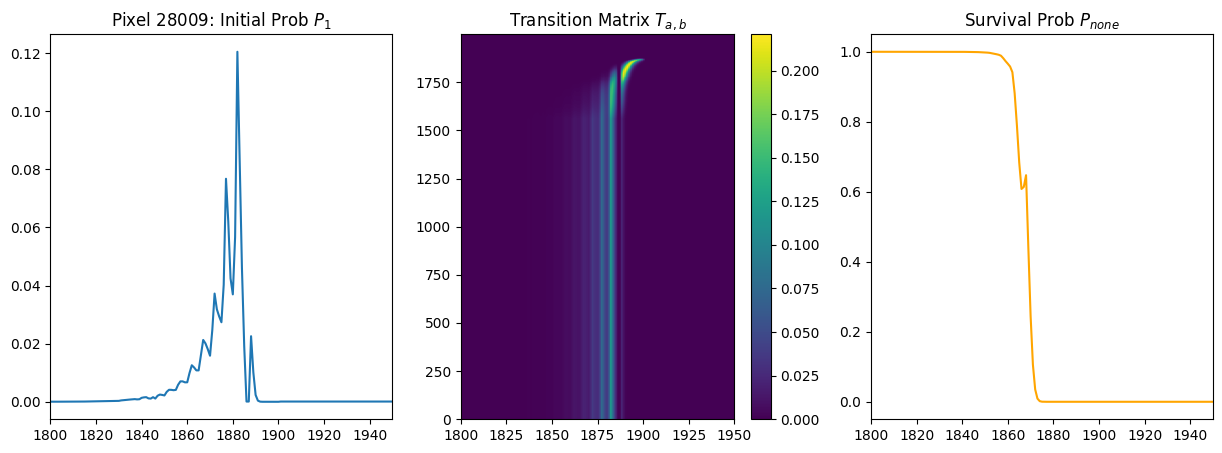

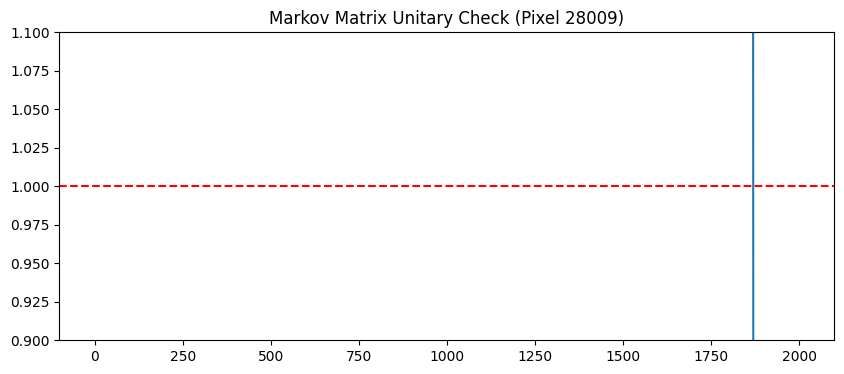

In [10]:
# --- Markov Diagnostic Visualization ---
final_pred = sim_markov.predict(ref_params, 
                                tracks_raw, track_fields, 42)

unique_pixels = final_pred['unique_pixels']
target_pixel_set = np.unique(target_data['pixel_id'])
valid_pix_idx = np.where(np.isin(unique_pixels, target_pixel_set) & (unique_pixels >= 0))[0]
if len(valid_pix_idx) > 0:
    pix_idx = valid_pix_idx[0]
    pixel_id = unique_pixels[pix_idx]
    
    log_p1 = final_pred['log_p1'][pix_idx]
    log_T = final_pred['log_T'][pix_idx]
    log_p_none = final_pred['log_p_none'][pix_idx]
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.plot(np.exp(log_p1))
    plt.xlim(1800, 1950)
    plt.title(f"Pixel {pixel_id}: Initial Prob $P_1$")
    plt.subplot(1, 3, 2)
    plt.imshow(np.exp(log_T), origin='lower', aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.xlim(1800, 1950)
    plt.title("Transition Matrix $T_{a,b}$")
    plt.subplot(1, 3, 3)
    plt.plot(np.exp(log_p_none), color='orange')
    plt.xlim(1800, 1950)
    plt.title("Survival Prob $P_{none}$")
    plt.show()
    
    row_sums = np.sum(np.exp(log_T), axis=1) + np.exp(log_p_none)
    plt.figure(figsize=(10, 4))
    plt.plot(row_sums, label='Row Sum (Hit + None)')
    plt.axhline(1.0, color='r', ls='--')
    plt.title(f"Markov Matrix Unitary Check (Pixel {pixel_id})")
    plt.ylim(0.9, 1.1)
    plt.show()
else:
    print("No matched pixels found.")